In [1]:
from pathlib import Path
import sys
import importlib
import time

import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.deep_learning.cnn_dataset as cnn_dataset
import src.deep_learning.cnn_model as cnn_model
import src.deep_learning.cnn_train as trainer

importlib.reload(cnn_dataset)
importlib.reload(cnn_model)
importlib.reload(trainer)

<module 'src.deep_learning.cnn_train' from 'c:\\Users\\HP\\Desktop\\RF Signal Processing\\RF-Signal-Classification-using-ML\\src\\deep_learning\\cnn_train.py'>

In [2]:
device = trainer.get_device()

print("="*60)
print("Device :", device)
print("="*60)

Device : cpu


In [3]:
DATA = PROJECT_ROOT / "data" / "processed"

X_train = np.load(DATA / "cnn_X_train.npy")
X_val   = np.load(DATA / "cnn_X_val.npy")
X_test  = np.load(DATA / "cnn_X_test.npy")

y_train = np.load(DATA / "cnn_y_train.npy")
y_val   = np.load(DATA / "cnn_y_val.npy")
y_test  = np.load(DATA / "cnn_y_test.npy")

print()

print("Training :", X_train.shape)

print("Validation :", X_val.shape)

print("Testing :", X_test.shape)


Training : (72000, 2, 128)
Validation : (9000, 2, 128)
Testing : (9000, 2, 128)


In [4]:
train_dataset = cnn_dataset.RadioMLDataset(
    X_train,
    y_train
)

val_dataset = cnn_dataset.RadioMLDataset(
    X_val,
    y_val
)

test_dataset = cnn_dataset.RadioMLDataset(
    X_test,
    y_test
)

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print()

print("Train Batches :", len(train_loader))

print("Validation Batches :", len(val_loader))

print("Test Batches :", len(test_loader))


Train Batches : 1125
Validation Batches : 141
Test Batches : 141


In [6]:
model = cnn_model.CNNModel(
    num_classes=9
)

model = model.to(device)

print(model)

print()

print(
    "Trainable Parameters :",
    cnn_model.count_parameters(model)
)

CNNModel(
  (stem): Sequential(
    (0): Conv1d(2, 64, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): ResidualBlock(
    (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (shortcut): Identity()
  )
  (layer2): ResidualBlock(
    (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(2,), padding=(1,), bias=False)
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-4

)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=3
)

In [8]:
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_path = MODEL_DIR / "cnn_best.pth"

history_path = MODEL_DIR / "cnn_history.json"

In [9]:
start = time.time()

history, best_accuracy = trainer.train_model(

    model,

    train_loader,

    val_loader,

    criterion,

    optimizer,

    scheduler,

    epochs=40,

    device=device,

    model_path=model_path,

    history_path=history_path

)

training_time = time.time() - start

print()

print("="*60)

print("Training Finished")

print()

print(f"Best Validation Accuracy : {best_accuracy:.4f}")

print()

print(f"Training Time : {training_time:.2f} seconds")

print("="*60)


Epoch 1/40


Train Loss : 0.3467
Train Accuracy : 0.8558
Validation Loss : 0.1596
Validation Accuracy : 0.9397

Best model saved.

Epoch 2/40


Train Loss : 0.1463
Train Accuracy : 0.9531
Validation Loss : 0.0962
Validation Accuracy : 0.9694

Best model saved.

Epoch 3/40


Train Loss : 0.0966
Train Accuracy : 0.9732
Validation Loss : 0.0592
Validation Accuracy : 0.9856

Best model saved.

Epoch 4/40


Train Loss : 0.0829
Train Accuracy : 0.9787
Validation Loss : 0.0635
Validation Accuracy : 0.9841

Epoch 5/40


...

Train Loss : 0.0482
Train Accuracy : 0.9884
Validation Loss : 0.0442
Validation Accuracy : 0.9899

Epoch 25/40


Train Loss : 0.0478
Train Accuracy : 0.9889
Validation Loss : 0.0478
Validation Accuracy : 0.9894

Epoch 26/40


Train Loss : 0.0473
Train Accuracy : 0.9887
Validation Loss : 0.0492
Validation Accuracy : 0.9891

Epoch 27/40


Train Loss : 0.0473
Train Accuracy : 0.9887
Validation Loss : 0.0499
Validation Accuracy : 0.9891

Epoch 28/40


Train Loss : 0.0384
Train Accuracy : 0.9913
Validation Loss : 0.0417
Validation Accuracy : 0.9907

Early stopping triggered.

Training Finished

Best Validation Accuracy : 0.9913

Training Time : 15521.90 seconds


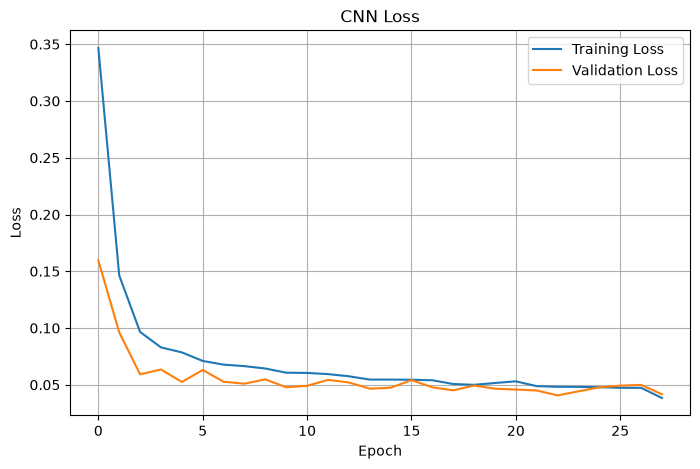

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("CNN Loss")

plt.legend()

plt.grid(True)

plt.show()

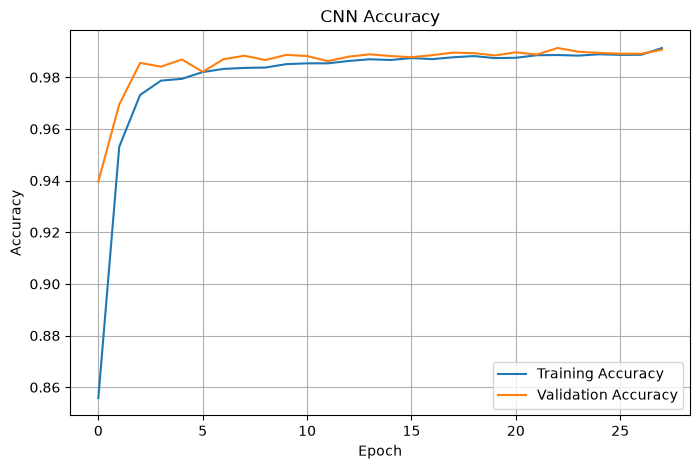

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("CNN Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [12]:
print("="*60)

print("Generated Files")

print("="*60)

for file in sorted(MODEL_DIR.iterdir()):

    print(file.name)

Generated Files
cnn.pt
cnn_best.pth
cnn_history.json
random_forest.pkl
random_forest_metadata.json
svm.pkl
